In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
ath = pd.read_csv(f"athletes.csv")
reg = pd.read_csv(f"regions.csv")
print("athletes:", ath.shape, "| regions:", reg.shape)

athletes: (13019, 15) | regions: (17, 3)


In [4]:
# ---- 1) MERGE the two datasets on NOC --------------------------------------
df = pd.merge(ath, reg, on="NOC", how="left")     # left-join keeps all athletes
print("\n[1] Merged shape:", df.shape, "| new columns:", ["region", "notes"])



[1] Merged shape: (13019, 17) | new columns: ['region', 'notes']


In [5]:
# ---- 2) Sport with the most GOLD medals (Top 5) ----------------------------
gold = df[df["Medal"] == "Gold"]                  # keep only gold rows
top5_gold = gold["Sport"].value_counts().head(5)
print("\n[2] Top 5 sports by Gold medals:")
print(top5_gold.to_string())


[2] Top 5 sports by Gold medals:
Athletics     101
Swimming       84
Rowing         53
Football       39
Gymnastics     36



[3] Female athletes per Summer Olympics (first & last few):
Year
1904     9
1908     9
1912    23
1920    28
...
Year
2004    154
2008    148
2012    158
2016    154


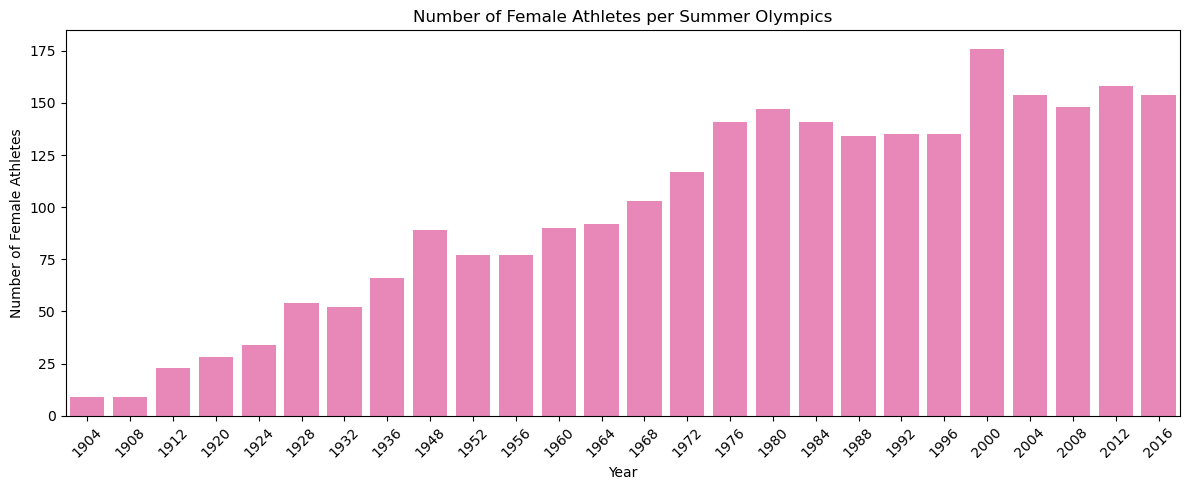

In [17]:
# ---- 3) Female athletes in each Summer Olympics + plot ---------------------
summer_f = df[(df["Season"] == "Summer") & (df["Sex"] == "F")]
fem_by_year = summer_f.groupby("Year").size()     # count per Summer year
print("\n[3] Female athletes per Summer Olympics (first & last few):")
print(fem_by_year.head(4).to_string()); print("..."); print(fem_by_year.tail(4).to_string())
plt.figure(figsize=(12, 5))
sns.barplot(x=fem_by_year.index, y=fem_by_year.values, color="#f778ba")
plt.title("Number of Female Athletes per Summer Olympics")
plt.xlabel("Year"); plt.ylabel("Number of Female Athletes")
plt.xticks(rotation=45); plt.tight_layout()
plt.show(); plt.close()


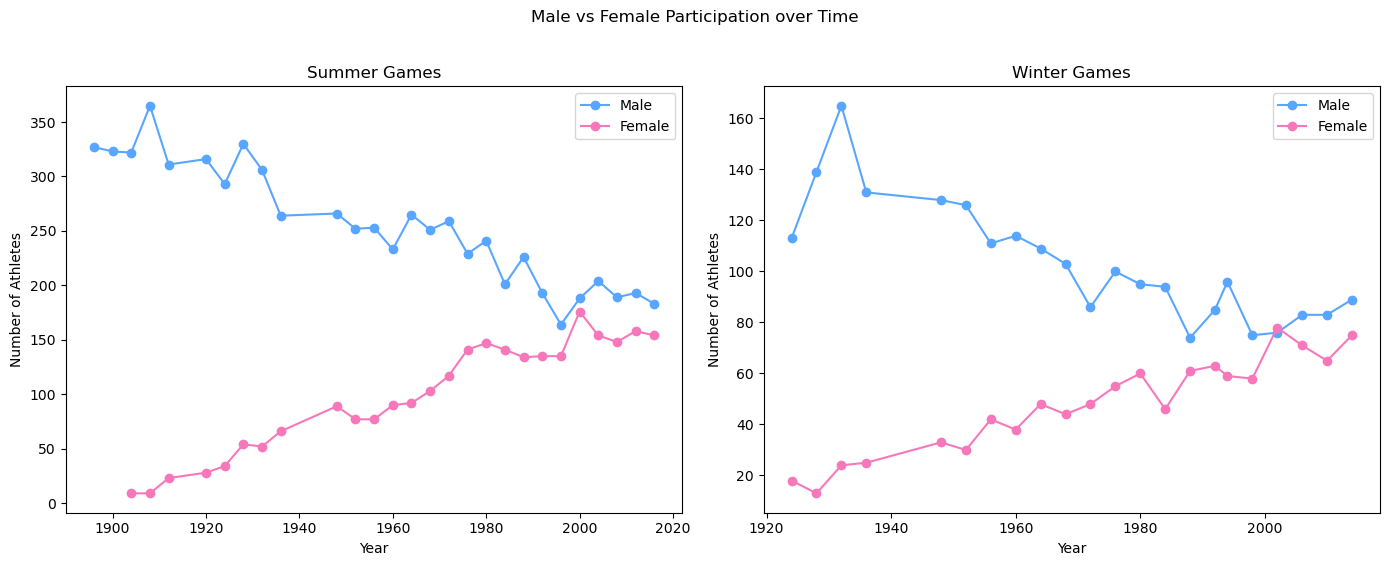


[4] line charts saved (Male/Female over years, Summer & Winter)


In [10]:
# ---- 4) Male vs Female participation over time, Summer AND Winter ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, season in zip(axes, ["Summer", "Winter"]):
    sub = df[df["Season"] == season]
    for sx, label, color in [("M", "Male", "#58a6ff"), ("F", "Female", "#f778ba")]:
        s = sub[sub["Sex"] == sx].groupby("Year").size()
        ax.plot(s.index, s.values, marker="o", label=label, color=color)
    ax.set_title(f"{season} Games"); ax.set_xlabel("Year")
    ax.set_ylabel("Number of Athletes"); ax.legend()
fig.suptitle("Male vs Female Participation over Time", y=1.02)
plt.tight_layout(); plt.show(); plt.close()
print("\n[4] line charts saved (Male/Female over years, Summer & Winter)")


In [11]:
# ---- 5) Year India won its FIRST Gold in the Summer Olympics ---------------
india_gold = df[(df["NOC"] == "IND") & (df["Season"] == "Summer") &
                (df["Medal"] == "Gold")]
print("\n[5] India's first Summer Gold year:", int(india_gold["Year"].min()))



[5] India's first Summer Gold year: 1928


In [12]:
# ---- 6) Body category column (Tall/Short x Heavy/Light) --------------------
# Height is in CM -> benchmark 1.8 m = 180 cm ; weight benchmark = 80 kg
def body_category(row):
    size = "Tall" if row["Height"] > 180 else "Short"
    mass = "Heavy" if row["Weight"] > 80 else "Light"
    return f"{size} and {mass}"
df["Body_Category"] = df.apply(body_category, axis=1)
print("\n[6] Body_Category counts:")
print(df["Body_Category"].value_counts().to_string())



[6] Body_Category counts:
Short and Light    8090
Tall and Light     2261
Short and Heavy    1958
Tall and Heavy      710


In [13]:
# ---- 7) Cities: Winter + Football + years 1930..2010 -----------------------
winter_fb = df[(df["Season"] == "Winter") & (df["Sport"] == "Football") &
               (df["Year"].between(1930, 2010))]
print("\n[7] Winter football cities (1930-2010):",
      winter_fb["City"].unique().tolist(),
      "  <-- empty: football is a SUMMER sport")
# helpful aside: the SAME pattern on Summer football returns real cities
summer_fb = df[(df["Season"] == "Summer") & (df["Sport"] == "Football") &
               (df["Year"].between(1930, 2010))]
print("    (Summer football cities, same query pattern):",
      sorted(summer_fb["City"].unique().tolist()))



[7] Winter football cities (1930-2010): []   <-- empty: football is a SUMMER sport
    (Summer football cities, same query pattern): ['Athina', 'Atlanta', 'Barcelona', 'Beijing', 'Berlin', 'Helsinki', 'London', 'Los Angeles', 'Melbourne', 'Mexico City', 'Montreal', 'Moskva', 'Munich', 'Roma', 'Seoul', 'Sydney', 'Tokyo']


In [14]:
# ---- 8) Player lookup function ---------------------------------------------
def player_profile(name):
    p = df[df["Name"] == name]
    return {
        "countries": p["Team"].unique().tolist(),
        "sports": p["Sport"].unique().tolist(),
        "olympics": p["Games"].unique().tolist(),
    }
print("\n[8] player_profile('Michael Wave'):")
print("   ", player_profile("Michael Wave"))


[8] player_profile('Michael Wave'):
    {'countries': ['United States'], 'sports': ['Swimming'], 'olympics': ['2004 Summer', '2008 Summer', '2012 Summer', '2016 Summer']}


In [16]:
# ---- 9) Sport with the most medals, Summer vs Winter separately ------------
medaled = df[df["Medal"].notna()]
summer_top = medaled[medaled["Season"] == "Summer"]["Sport"].value_counts()
winter_top = medaled[medaled["Season"] == "Winter"]["Sport"].value_counts()
print("\n[9] Most medals - Summer:", summer_top.idxmax(), f"({summer_top.max()})",
      "| Winter:", winter_top.idxmax(), f"({winter_top.max()})")




[9] Most medals - Summer: Athletics (291) | Winter: Ice Hockey (94)
